# 📌 ¿Qué es K-Nearest Neighbors (KNN)?

**K-Nearest Neighbors (KNN)** es un algoritmo de aprendizaje supervisado que se utiliza tanto para clasificación como para regresión. Su idea principal es predecir la etiqueta de un dato nuevo observando las etiquetas de sus **k vecinos más cercanos** en el conjunto de entrenamiento.

- 📦 No requiere entrenamiento: es un algoritmo **"lazy"**, no construye un modelo explícito.
- 📏 Usa métricas de distancia (como Euclidiana) para encontrar los vecinos más cercanos.
- 🧠 Clasifica el nuevo punto según la mayoría de clases entre los vecinos.

# EJEMPLO DE KNN CON DATASET PENGUINS

## 1 - IMPORTAMOS LIBRERIAS MAS COMUNES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [ ]:
penguins_df = sns.load_dataset('penguins').dropna()
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## 3 - EDA

In [ ]:
penguins_df.shape

(333, 7)

In [ ]:
penguins_df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


### 3.1 REVISAMOS LAS DIFERENTES ESPECIES DE PINGUINOS PARA PODER CREAR UN MODELO DE CLASIFICACIÓN

In [ ]:
penguins_df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


### 3.2 CODIFICACIÓN DE VARIABLES CATEGORICA SPECIES

In [ ]:
penguins_df.loc[:,'species'] = penguins_df['species'].map({'Adelie':0,'Gentoo':1,'Chinstrap':2})
penguins_df.loc[:,'sex'] = penguins_df['sex'].map({'Male':0,'Female':1})
penguins_df['species'] = penguins_df['species'].astype(int)
penguins_df['sex'] = penguins_df['sex'].astype(int)


In [ ]:
penguins_df.dtypes

,0
species,int64
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,int64


# 4 - CREACIÓN DE MODELO KNN

## 4.1 IDENTIFICAMOS VARIABLES X y Y

In [ ]:
X = penguins_df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']]  # Seleccionar características
y = penguins_df['species']

## 4.2 IMPORTAMOS LIBRERIAS

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score

## 4.3 DIVIDIMOS EL DATASET EN ENTRENAMIENTO Y PRUEBA

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 4.4 ESCALAMOS LOS DATOS

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## 4.5 CREO EL MODELO KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

## 4.6 EVALUAMOS RESULTADOS

In [ ]:
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       1.00      1.00      1.00        23
           2       0.93      1.00      0.96        13

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



**Precisión (Precision)**: Proporción de predicciones correctas de una clase entre todas las predicciones realizadas para esa clase.

**Exhaustividad (Recall)**: Proporción de instancias correctamente clasificadas en una clase entre todas las instancias reales de esa clase.

**F1-score**: Media armónica entre precisión y exhaustividad, útil cuando hay un balance desigual entre clases.

**Soporte (Support)**: Número total de ejemplos de cada clase en los datos de prueba.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.99


# VERIFICAMOS SOBREAJUSTE(OVERFITTING) CON VALIDACIÓN CRUZADA

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, X_train, y_train, cv=5)
print(f'Cross-validation scores: {scores}')
print(f'Mean cross-validation accuracy: {scores.mean():.2f}')

Cross-validation scores: [0.66666667 0.83018868 0.79245283 0.73584906 0.69811321]
Mean cross-validation accuracy: 0.74


# PROBAR EL MODELO CON DIFERENTES VALORES DE K

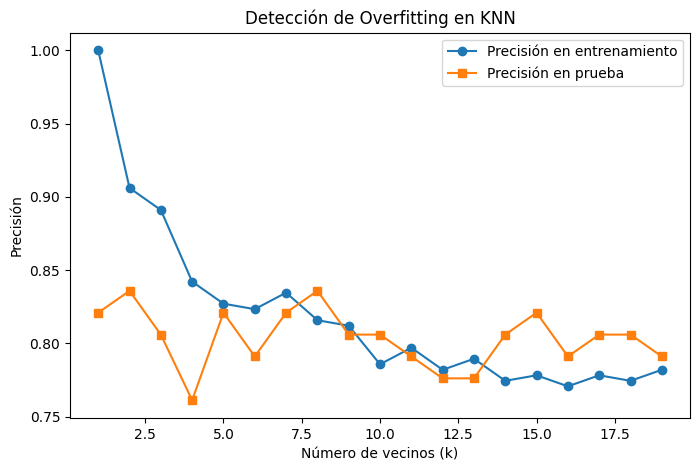

In [ ]:
neighbors = np.arange(1, 20)
train_accuracy = []
test_accuracy = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

# Graficar la precisión en entrenamiento y prueba
plt.figure(figsize=(8, 5))
plt.plot(neighbors, train_accuracy, label='Precisión en entrenamiento', marker='o')
plt.plot(neighbors, test_accuracy, label='Precisión en prueba', marker='s')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión')
plt.title('Detección de Overfitting en KNN')
plt.legend()
plt.show()